### CPI(Consumer Price Index) Analysis
- Missing & duplicate values analysis
- Inflation cycle
- Split of inflation cycles(low, medium,high)
- Longest spread of each cycle
- Relation of CPI with WPI
- Relation of CPI with market

In [2]:
import numpy as np
import pandas as pd
import os


In [3]:
cwd = os.getcwd()
dataset_folder_path = os.path.join(cwd, "..\\data_clean")
dataset_path = os.path.join(dataset_folder_path, "cpi.csv")
cpi_df = pd.read_csv(dataset_path)

cpi_df.head()


,release_date,actual,forecast,previous
0,12-06-2026,0.0393,0.0400,0.0348
1,12-05-2026,0.0348,0.0380,0.0340
2,13-04-2026,0.0340,0.0348,0.0321
3,12-03-2026,0.0321,0.0310,0.0273
4,12-02-2026,0.0275,0.0240,0.0133


In [4]:
cpi_df['release_date'] = pd.to_datetime(cpi_df['release_date'], format='%d-%m-%Y')


In [5]:
# Data Quality Checks
print(f"Missing values:\n{cpi_df.isna().sum()}\n")
print(f"Duplicates count:\n{cpi_df.duplicated().sum()}")


Missing values:
release_date    0
actual          0
forecast        1
previous        0
dtype: int64

Duplicates count:
0


### Inflation Analysis

In [6]:
def categorize_cpi(value):
    if value <= 0.02:
        return "Low"
    elif value <= 0.06:
        return "Stable"
    else:
        return "High"


cpi_df["inflation_category"] = cpi_df["actual"].apply(categorize_cpi)

cpi_df.head()


,release_date,actual,forecast,previous,inflation_category
0,2026-06-12,0.0393,0.0400,0.0348,Stable
1,2026-05-12,0.0348,0.0380,0.0340,Stable
2,2026-04-13,0.0340,0.0348,0.0321,Stable
3,2026-03-12,0.0321,0.0310,0.0273,Stable
4,2026-02-12,0.0275,0.0240,0.0133,Stable


In [7]:
# Number of inflation cycles
print("Inflation Cycles Count:\n", cpi_df['inflation_category'].value_counts())
cycles_perc = (cpi_df['inflation_category'].value_counts()/cpi_df.shape[0])*100

print("\nInflation Cycles in Percentage:\n", cycles_perc)


Inflation Cycles Count:
 inflation_category
Stable    106
High       58
Low         6
Name: count, dtype: int64

Inflation Cycles in Percentage:
 inflation_category
Stable    62.352941
High      34.117647
Low        3.529412
Name: count, dtype: float64


### Observation
* There in Wholesale price index low & high were much more frequent while for CPI medium inflation being **medium** is much more frequent and either **high** but inflation being  low is very low as India is a consumption based country

In [8]:
# Computing streak lengths
# Lets analyze longest hawkish & dovish regimes
def get_longest_calendar_streak(data, target_regime):
    # Create a boolean series for the target regime
    is_target = data["inflation_category"] == target_regime

    # Group contiguous blocks of the same regime
    blocks = (is_target != is_target.shift()).cumsum()

    # Create a dictionary to hold stats for each block
    block_stats = []

    # Iterate through each unique block of the target regime
    for block_id, group in data[is_target].groupby(blocks):
        start_date = group["release_date"].min()
        end_date = group["release_date"].max()

        # Calculate calendar duration in days
        duration_days = (end_date - start_date).days

        block_stats.append(
            {
                "inflation_category": target_regime,
                "start_date": start_date,
                "end_date": end_date,
                "duration_days": duration_days,
                "record_count": len(group),
            }
        )

    if not block_stats:
        return None

    # Convert to DataFrame and find the block with the maximum calendar duration (days)
    stats_df = pd.DataFrame(block_stats)
    longest_streak = stats_df.loc[stats_df["duration_days"].idxmax()]
    return longest_streak


In [9]:
high_streak = get_longest_calendar_streak(cpi_df, "High")
low_streak = get_longest_calendar_streak(cpi_df, "Low")

# 4. Display the results
print("=" * 55)
print("        LONGEST REGIME STREAKS (BY CALENDAR TIME)      ")
print("=" * 55)

for streak in [high_streak, low_streak]:
    if streak is not None:
        print(f"Inflation Category:            {streak['inflation_category']}")
        print(
            f"Timeline:          {
                streak['start_date'].strftime('%Y-%m-%d')}  to  {
                streak['end_date'].strftime('%Y-%m-%d')}")
        print(f"Calendar Duration: {streak['duration_days']} days")
        print(f"Data Points Count: {streak['record_count']} records")
        print("-" * 55)
    else:
        print("No periods found for this regime.\n")


        LONGEST REGIME STREAKS (BY CALENDAR TIME)      
Inflation Category:            High
Timeline:          2010-06-30  to  2014-10-13
Calendar Duration: 1566 days
Data Points Count: 31 records
-------------------------------------------------------
Inflation Category:            Low
Timeline:          2025-10-13  to  2026-01-12
Calendar Duration: 91 days
Data Points Count: 4 records
-------------------------------------------------------


### Observations
* Post 2008 Crash during recovery cycle as there was boom the WPI got increased
* Due to AI wave firings started & panic started also job market was down due to which consumption slowed down.

In [10]:
wpi_df_path = os.path.join(dataset_folder_path, "wpi.csv")
wpi_df = pd.read_csv(wpi_df_path)

wpi_df.head()


,release_date,actual,forecast,previous
0,15-06-2026,0.0968,0.0910,0.0830
1,14-05-2026,0.0830,0.0440,0.0388
2,15-04-2026,0.0388,0.0300,0.0213
3,16-03-2026,0.0213,0.0200,0.0181
4,16-02-2026,0.0181,0.0125,0.0083


In [11]:
wpi_df['release_date'] = pd.to_datetime(wpi_df['release_date'])

# To avoid confusion b/n interest rate columns & wpi columns  lets change column names
cpi_df.rename(columns={'actual': 'cpi'}, inplace=True)
wpi_df.rename(columns={'actual': 'wpi'}, inplace=True)

# Merging CPI & WPI
# 1. Sort and save the left DataFrame
cpi_df = cpi_df.sort_values(by='release_date')

# 2. Sort and save the right DataFrame (merge_asof requires both to be sorted)
wpi_df = wpi_df.sort_values(by='release_date')


merged_df = pd.merge_asof(
    cpi_df,
    wpi_df,
    on='release_date',
    direction='nearest'
)

merged_df.head()


C:\Users\Admin\AppData\Local\Temp\ipykernel_11536\2407383618.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  wpi_df['release_date'] = pd.to_datetime(wpi_df['release_date'])


,release_date,cpi,forecast_x,previous_x,inflation_category,wpi,forecast_y,previous_y
0,2010-06-30,0.139,0.132,0.133,High,0.1025,NaN,0.1048
1,2010-08-02,0.137,0.137,0.139,High,0.0998,NaN,0.1025
2,2010-09-02,0.113,0.104,0.137,High,0.0887,NaN,0.0998
3,2010-10-01,0.099,0.100,0.113,High,0.0898,NaN,0.0887
4,2010-11-01,0.098,0.092,0.099,High,0.0908,NaN,0.0898


In [12]:
# Mapping correlation between them
non_str_cols = merged_df.select_dtypes(exclude=['object', 'string']).columns.tolist()

merged_df_corr = merged_df[non_str_cols].corr()
merged_df_corr['cpi']


release_date   -0.579466
cpi             1.000000
forecast_x      0.987933
previous_x      0.953789
wpi             0.447072
forecast_y      0.355864
previous_y      0.439008
Name: cpi, dtype: float64

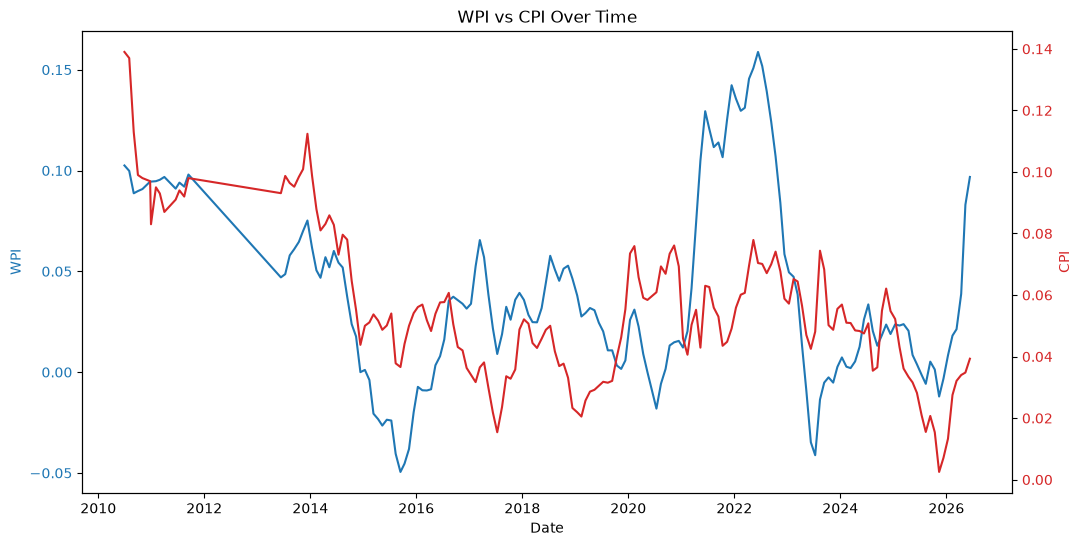

In [13]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# WPI
ax1.set_xlabel("Date")
ax1.set_ylabel("WPI", color="tab:blue")
ax1.plot(merged_df["release_date"], merged_df["wpi"], color="tab:blue", label="WPI")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Interest rate on second axis
ax2 = ax1.twinx()
ax2.set_ylabel("CPI", color="tab:red")
ax2.plot(merged_df["release_date"], merged_df["cpi"], color="tab:red", label="CPI")
ax2.tick_params(axis='y', labelcolor="tab:red")

plt.title("WPI vs CPI Over Time")
plt.show()


### Observation
* We can see there is medium correlation between CPI & WPI also CPI follows WPI as well. 
* The magnitude differs as central banks regulate the consumer inflation

### CPI vs Interest Rates

In [14]:
interest_rate_df_path = os.path.join(dataset_folder_path, "interest_rates.csv")
interest_rate_df = pd.read_csv(interest_rate_df_path)

interest_rate_df['release_date'] = pd.to_datetime(interest_rate_df['release_date'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_11536\692748825.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  interest_rate_df['release_date'] = pd.to_datetime(interest_rate_df['release_date'])


In [15]:
# To avoid confusion b/n interest rate columns & wpi columns  lets change column names
interest_rate_df.rename(columns={'actual': 'interest_rate'}, inplace=True)

interest_rate_df = interest_rate_df.sort_values(by='release_date')


merged_interest_df = pd.merge_asof(
    merged_df,
    interest_rate_df,
    on='release_date',
    direction='nearest'
)

merged_interest_df.tail()


,release_date,cpi,forecast_x,previous_x,inflation_category,wpi,forecast_y,previous_y,interest_rate,forecast,previous
165,2026-02-12,0.0275,0.0240,0.0133,Stable,0.0181,0.0125,0.0083,0.0525,0.0525,0.0525
166,2026-03-12,0.0321,0.0310,0.0273,Stable,0.0213,0.0200,0.0181,0.0525,0.0525,0.0525
167,2026-04-13,0.0340,0.0348,0.0321,Stable,0.0388,0.0300,0.0213,0.0525,0.0525,0.0525
168,2026-05-12,0.0348,0.0380,0.0340,Stable,0.0830,0.0440,0.0388,0.0525,0.0525,0.0525
169,2026-06-12,0.0393,0.0400,0.0348,Stable,0.0968,0.0910,0.0830,0.0525,0.0525,0.0525


In [16]:
# Mapping correlation between them
non_str_cols = merged_interest_df.select_dtypes(exclude=['object', 'string']).columns.tolist()

merged_interest_df_corr = merged_interest_df[non_str_cols].corr()
merged_interest_df_corr['cpi']


release_date    -0.579466
cpi              1.000000
forecast_x       0.987933
previous_x       0.953789
wpi              0.447072
forecast_y       0.355864
previous_y       0.439008
interest_rate    0.305158
forecast         0.214902
previous         0.260163
Name: cpi, dtype: float64

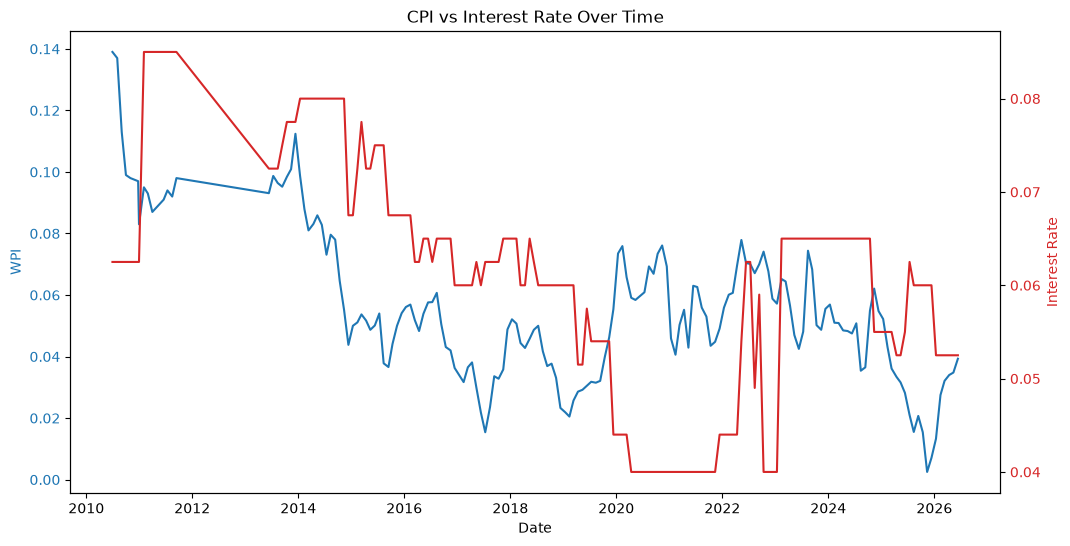

In [17]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# WPI
ax1.set_xlabel("Date")
ax1.set_ylabel("WPI", color="tab:blue")
ax1.plot(
    merged_interest_df["release_date"],
    merged_interest_df["cpi"],
    color="tab:blue",
    label="CPI")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Interest rate on second axis
ax2 = ax1.twinx()
ax2.set_ylabel("Interest Rate", color="tab:red")
ax2.plot(
    merged_interest_df["release_date"],
    merged_interest_df["interest_rate"],
    color="tab:red",
    label="Interest Rate")
ax2.tick_params(axis='y', labelcolor="tab:red")

plt.title("CPI vs Interest Rate Over Time")
plt.show()


### Observations
* There is weak correlation between CPI & Interest Rates
* CPI - WPI: ~43% corelation
* CPI - Interest Rate: ~22% corelation

### News Analysis
* Data Quality (Missing dates  and Duplicate headlines )
* Sentiment Analysis: News being (Positive, Neutral, Negative)
* Sentiment distribution overall and by year
* Create categories: (Economy ,Politics, Elections, Budget, Banking, Geopolitics, Corporate)
* Theme frequency by year

In [18]:
news_df_path = os.path.join(dataset_folder_path, "news.csv")
news_df = pd.read_csv(news_df_path)

news_df.head()


,News_id,News_Description,start_date,end_date,duration
0,1,Reliance Power IPO disappointment after India'...,21-01-08,21-01-08,1
1,2,Collapse of Lehman Brothers and Global Financi...,15-09-08,15-09-08,1
2,3,Global Financial Crisis affects Indian corpora...,16-09-08,31-10-08,45
3,4,Emergency RBI rate cut and liquidity support,20-10-08,20-10-08,1
4,5,Aggressive RBI stimulus package (repo and CRR ...,02-01-09,02-01-09,1


Before we begin 2 libraries are needed to be installed
* Torch
* Transformers

In [19]:
news_df['start_date'] = pd.to_datetime(news_df['start_date'])
news_df['end_date'] = pd.to_datetime(news_df['end_date'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_11536\1119307714.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  news_df['start_date'] = pd.to_datetime(news_df['start_date'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_11536\1119307714.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  news_df['end_date'] = pd.to_datetime(news_df['end_date'])


In [20]:
from transformers import pipeline

print('pipeline imported successfully')


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pipeline imported successfully


In [51]:
# === CATEGORY ANALYSIS ===
cat_classifier = pipeline(
    "zero-shot-classification",
    model="typeform/distilbert-base-uncased-mnli"
)

candidate_categories = [
    "Politics", "Economics & Finance", "Technology",
    "Health & Medicine", "Environment & Climate", "Science",
    "Sports", "Entertainment & Culture", "Crime & Law",
    "Disaster & Accident", "Education", "Military & Defense"
]


def classify_category(text):
    if pd.isna(text) or text.strip() == '':
        return []
    result = cat_classifier(text, candidate_categories, multi_label=True)
    if result["scores"][0] >= 0.5:
        return result["labels"][0]
    return "Unknown"


news_df["Category"] = news_df["News_Description"].apply(classify_category)
print('Category analysis done')
news_df[['News_id', 'News_Description', 'Category']].head()


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3646.37it/s]


Category analysis done


,News_id,News_Description,Category
0,1,Reliance Power IPO disappointment after India'...,Unknown
1,2,Collapse of Lehman Brothers and Global Financi...,Economics & Finance
2,3,Global Financial Crisis affects Indian corpora...,Economics & Finance
3,4,Emergency RBI rate cut and liquidity support,Health & Medicine
4,5,Aggressive RBI stimulus package (repo and CRR ...,Environment & Climate


In [52]:
news_df['Category']


0                     Unknown
1         Economics & Finance
2         Economics & Finance
3           Health & Medicine
4       Environment & Climate
5                     Unknown
6                  Technology
7                    Politics
8                    Politics
9                    Politics
10                   Politics
11                   Politics
12                   Politics
13      Environment & Climate
14        Economics & Finance
15                 Technology
16      Environment & Climate
17                 Technology
18          Health & Medicine
19                Crime & Law
20        Economics & Finance
21        Economics & Finance
22                    Unknown
23                    Unknown
24                   Politics
25        Economics & Finance
26          Health & Medicine
27                    Unknown
28                Crime & Law
29          Health & Medicine
30                   Politics
31          Health & Medicine
32    Entertainment & Culture
33        

In [22]:
# === SENTIMENT ANALYSIS ===
sentiment_classifier = pipeline("sentiment-analysis")


def get_sentiment(text):
    if pd.isna(text) or text.strip() == '':
        return {'label': None, 'score': None}
    result = sentiment_classifier(text, truncation=True, max_length=512)[0]
    return {'label': result['label'], 'score': round(result['score'], 4)}


sentiment_results = news_df["News_Description"].apply(get_sentiment)
news_df["Sentiment"] = sentiment_results.apply(lambda x: x['label'])
news_df["Sentiment_Score"] = sentiment_results.apply(lambda x: x['score'])
print('Sentiment analysis done')
news_df[['News_id', 'News_Description', 'Sentiment']].head()


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1311.58it/s]


Sentiment analysis done


,News_id,News_Description,Sentiment
0,1,Reliance Power IPO disappointment after India'...,NEGATIVE
1,2,Collapse of Lehman Brothers and Global Financi...,NEGATIVE
2,3,Global Financial Crisis affects Indian corpora...,NEGATIVE
3,4,Emergency RBI rate cut and liquidity support,POSITIVE
4,5,Aggressive RBI stimulus package (repo and CRR ...,NEGATIVE


In [23]:
# === SEVERITY ANALYSIS ===
severity_classifier = pipeline(
    "zero-shot-classification",
    model="typeform/distilbert-base-uncased-mnli"
)

severity_levels = ["Critical", "High", "Moderate", "Low", "Minimal"]


def classify_severity(text):
    if pd.isna(text) or text.strip() == '':
        return None
    result = severity_classifier(text, severity_levels, multi_label=False)
    return result['labels'][0]


news_df["Severity"] = news_df["News_Description"].apply(classify_severity)
print('Severity analysis done')
news_df[['News_id', 'News_Description', 'Severity']].head()


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8132.13it/s]


Severity analysis done


,News_id,News_Description,Severity
0,1,Reliance Power IPO disappointment after India'...,Low
1,2,Collapse of Lehman Brothers and Global Financi...,Critical
2,3,Global Financial Crisis affects Indian corpora...,Critical
3,4,Emergency RBI rate cut and liquidity support,Critical
4,5,Aggressive RBI stimulus package (repo and CRR ...,Critical


In [53]:
# Saving file for modelling
output_file_path = os.path.join(cwd, "..\\data_model\\dim_news1.csv")
news_df.to_csv(output_file_path)


In [25]:
# === SUMMARY & EXPORT ===
print('\n=== Category Distribution ===')
cat_counts = news_df.explode('Category')['Category'].value_counts()
print(cat_counts.to_string())

print('\n=== Sentiment Distribution ===')
print(news_df['Sentiment'].value_counts().to_string())

print('\n=== Severity Distribution ===')
print(news_df['Severity'].value_counts().to_string())



=== Category Distribution ===
Category
Technology    1
Politics      1

=== Sentiment Distribution ===
Sentiment
NEGATIVE    33
POSITIVE    16

=== Severity Distribution ===
Severity
Critical    27
Moderate    15
Minimal      4
Low          2
High         1


In [26]:
news_df['year'] = news_df['start_date'].dt.year


In [27]:
# Getting sentiment distribution per year
counts = news_df.groupby("year")["Sentiment"].value_counts()
counts


year  Sentiment
2008  NEGATIVE     3
      POSITIVE     1
2009  NEGATIVE     2
      POSITIVE     2
2010  NEGATIVE     1
2013  NEGATIVE     2
      POSITIVE     1
2014  POSITIVE     1
2015  NEGATIVE     3
      POSITIVE     1
2016  NEGATIVE     2
      POSITIVE     1
2017  NEGATIVE     1
2018  NEGATIVE     3
2019  POSITIVE     2
2020  NEGATIVE     4
      POSITIVE     2
2021  NEGATIVE     2
2022  NEGATIVE     3
2023  NEGATIVE     3
      POSITIVE     2
2024  NEGATIVE     3
      POSITIVE     1
2025  POSITIVE     1
2026  POSITIVE     1
      NEGATIVE     1
Name: count, dtype: int64

In [28]:
sentiment_perc = (news_df['Sentiment'].value_counts() / news_df.shape[0])
sentiment_perc


Sentiment
NEGATIVE    0.673469
POSITIVE    0.326531
Name: count, dtype: float64

In [29]:
# Getting sentiment distribution per year
df_exploded = news_df.explode("Category")

category_counts = (
    df_exploded
    .groupby("year")["Category"]
    .value_counts()
    .unstack(fill_value=0)
)

print(category_counts)


Category  Technology  Politics
year                          
2009               1         0
2010               0         1


### Events Analysis
1. Data Quality Checks
2. CAtegorize: (Financial Crisis, Pandemic, War, Central Bank Action, Election, Commodity Shock)
3. Which category appears most 
4. Events per year
5. Crisis clusters
6. Classify short-term & long term events
7. Categorize severity


In [30]:
events_df_path = os.path.join(dataset_folder_path, "events.csv")
events_df = pd.read_csv(events_df_path)
events_df.head()


,Event_id,Event_Description,start_date,end_date,duration_days
0,1,Lehman Brothers Bankruptcy,15-09-2008,15-09-2008,1.0
1,2,AIG Bailout,16-09-2008,16-09-2008,1.0
2,3,Global Stock Market Crash (2008) –,16-09-2008,31-10-2008,45.0
3,4,Gaza War,27-12-2008,19-01-2009,23.0
4,5,Arab Springs,13-12-2010,13-12-2010,1.0


In [31]:
# Data Quality Checks
# Missing value count
print("\nMissing values count:\n", events_df.isna().sum())

# Duplicate Count checks
print("\n Duplicate count:\n", events_df.duplicated().sum())



Missing values count:
 Event_id             0
Event_Description    0
start_date           0
end_date             0
duration_days        1
dtype: int64

 Duplicate count:
 0


In [32]:
events_df['start_date'] = pd.to_datetime(events_df['start_date'], format='%d-%m-%Y')
events_df['end_date'] = pd.to_datetime(events_df['end_date'], format='%d-%m-%Y')
events_df['year'] = events_df['start_date'].dt.year


In [33]:
# Events by year
events_df['year'].value_counts().sort_index()


year
2008    4
2010    1
2011    2
2012    1
2015    2
2016    2
2017    1
2018    3
2019    1
2020    6
2021    2
2022    4
2023    1
2024    4
2025    3
2026    2
Name: count, dtype: int64

In [34]:
# Short term & long term events counts
short_term_count = (events_df['duration_days'] <= 30).sum()
long_term_count = (events_df['duration_days'] > 30).sum()

print(short_term_count/events_df.shape[0])
print(long_term_count/events_df.shape[0])


0.5897435897435898
0.38461538461538464


In [35]:
# Events by year
short_term_by_year = (
    events_df[events_df["duration_days"] <= 30]
    .groupby("year")
    .size()
)

long_term_by_year = (
    events_df[events_df["duration_days"] > 30]
    .groupby("year")
    .size()
)


### Category Analysis

In [36]:
from transformers import pipeline

print('pipeline imported successfully')


pipeline imported successfully


In [56]:
# === CATEGORY ANALYSIS ===
cat_classifier = pipeline(
    "zero-shot-classification",
    model="typeform/distilbert-base-uncased-mnli"
)

candidate_categories = [
    "Politics", "Economics & Finance", "Technology",
    "Healthcare", "Environment & Climate", "Science",
    "Sports", "Entertainment", "Crime & Law",
    "Disaster", "Education", "Military & Defense"
]


def classify_category(text):
    if pd.isna(text) or text.strip() == '':
        return []
    result = cat_classifier(text, candidate_categories, multi_label=True)
    # We want to take only one category
    if result['scores'][0] >= 0.5:
        return result['labels'][0]
    return "Unknown"


events_df["category"] = events_df["Event_Description"].apply(classify_category)
print('Category analysis done')
events_df[['Event_id', 'Event_Description', 'category']].head()


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2176.40it/s]


Category analysis done


,Event_id,Event_Description,category
0,1,Lehman Brothers Bankruptcy,Economics & Finance
1,2,AIG Bailout,Environment & Climate
2,3,Global Stock Market Crash (2008) –,Economics & Finance
3,4,Gaza War,Military & Defense
4,5,Arab Springs,Environment & Climate


In [38]:
# Getting most repeated category
categories = events_df.explode('category')['category'].value_counts()
categories


category
Environment & Climate    1
Name: count, dtype: int64

In [39]:
# Crisis Clusters
crisis_clusters = events_df.groupby("year").size()

print(crisis_clusters)


year
2008    4
2010    1
2011    2
2012    1
2015    2
2016    2
2017    1
2018    3
2019    1
2020    6
2021    2
2022    4
2023    1
2024    4
2025    3
2026    2
dtype: int64


### Sentiment Analysis

In [57]:
sentiment_classifier = pipeline("sentiment-analysis")


def get_sentiment(text):
    if pd.isna(text) or text.strip() == '':
        return {'label': None, 'score': None}
    result = sentiment_classifier(text, truncation=True, max_length=512)[0]
    return {'label': result['label'], 'score': round(result['score'], 4)}


sentiment_results = events_df["Event_Description"].apply(get_sentiment)
events_df["sentiment"] = sentiment_results.apply(lambda x: x['label'])
events_df["sentiment_Score"] = sentiment_results.apply(lambda x: x['score'])
print('Sentiment analysis done')
events_df[['Event_Description', 'sentiment']].head()


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1795.32it/s]


Sentiment analysis done


,Event_Description,sentiment
0,Lehman Brothers Bankruptcy,NEGATIVE
1,AIG Bailout,NEGATIVE
2,Global Stock Market Crash (2008) –,NEGATIVE
3,Gaza War,NEGATIVE
4,Arab Springs,POSITIVE


### Severity Analysis

In [58]:
severity_classifier = pipeline(
    "zero-shot-classification",
    model="typeform/distilbert-base-uncased-mnli"
)

severity_levels = ["Critical", "High", "Moderate", "Low", "Minimal"]


def classify_severity(text):
    if pd.isna(text) or text.strip() == '':
        return None
    result = severity_classifier(text, severity_levels, multi_label=False)
    return result['labels'][0]


events_df["severity"] = events_df["Event_Description"].apply(classify_severity)
print('Severity analysis done')
events_df[['Event_Description', 'severity']].head()


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6476.73it/s]


Severity analysis done


,Event_Description,severity
0,Lehman Brothers Bankruptcy,Moderate
1,AIG Bailout,Minimal
2,Global Stock Market Crash (2008) –,Minimal
3,Gaza War,Critical
4,Arab Springs,Moderate


In [42]:
# Summary
# === SUMMARY & EXPORT ===
print('\n=== Category Distribution ===')
cat_counts = news_df.explode('Category')['Category'].value_counts()
print(cat_counts.to_string())

print('\n=== Sentiment Distribution ===')
print(news_df['Sentiment'].value_counts().to_string())

print('\n=== Severity Distribution ===')
print(news_df['Severity'].value_counts().to_string())



=== Category Distribution ===
Category
Technology    1
Politics      1

=== Sentiment Distribution ===
Sentiment
NEGATIVE    33
POSITIVE    16

=== Severity Distribution ===
Severity
Critical    27
Moderate    15
Minimal      4
Low          2
High         1


**Note:** The categories,sentiment and severity are not accurate as this was a zero shot prompting there is a scope of improvement to fine tune news & events analysis.

* Also it requires a bit cleaning after the saving of data

In [59]:
# Saving events dataset for modelling
file_path = os.path.join(cwd, "..\\data_model\\events.csv")
events_df.to_csv(file_path)
